In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

E0000 00:00:1780986342.652043      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780986342.713820      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780986343.210559      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780986343.210693      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780986343.210696      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780986343.210699      58 computation_placer.cc:177] computation placer already registered. Please check linka

In [2]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.cifar10.load_data()

x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0

y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

print(x_train.shape)
print(x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [3]:
IMG_SIZE = 96

x_train = tf.image.resize(
    x_train,
    (IMG_SIZE, IMG_SIZE)
).numpy()

x_test = tf.image.resize(
    x_test,
    (IMG_SIZE, IMG_SIZE)
).numpy()

print(x_train.shape)
print(x_test.shape)

I0000 00:00:1780986369.379008      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


(50000, 96, 96, 3)
(10000, 96, 96, 3)


In [4]:
import numpy as np

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

labels = np.argmax(y_train, axis=1)

unique, counts = np.unique(
    labels,
    return_counts=True
)

for idx, count in zip(unique, counts):
    print(
        f"{class_names[idx]} : {count}"
    )

airplane : 5000
automobile : 5000
bird : 5000
cat : 5000
deer : 5000
dog : 5000
frog : 5000
horse : 5000
ship : 5000
truck : 5000


In [5]:
base_model = MobileNet(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

outputs = Dense(
    10,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

model.summary()

/tmp/ipykernel_58/2794889684.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 48, 48, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 48, 48, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 48, 48, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 48, 48, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 24, 24, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 24, 24, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 24, 24, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 24, 24, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,239,114 (12.36 MB)

 Trainable params: 10,250 (40.04 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [6]:
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10


I0000 00:00:1780986408.516905     128 service.cc:152] XLA service 0x7aa5f80023d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780986408.516985     128 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780986410.996460     128 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780986426.835240     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


352/352 ━━━━━━━━━━━━━━━━━━━━ 80s 130ms/step - accuracy: 0.4026 - loss: 2.1750 - val_accuracy: 0.6558 - val_loss: 1.0634
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.6650 - loss: 1.0697 - val_accuracy: 0.7530 - val_loss: 0.7556
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.7473 - loss: 0.7913 - val_accuracy: 0.7954 - val_loss: 0.6245
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.7915 - loss: 0.6384 - val_accuracy: 0.8246 - val_loss: 0.5449
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.8253 - loss: 0.5349 - val_accuracy: 0.8406 - val_loss: 0.4934
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.8475 - loss: 0.4588 - val_accuracy: 0.8530 - val_loss: 0.4534
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.8636 - loss: 0.4067 - val_accuracy: 0.8612 - val_loss: 0.4262
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.8797 - loss: 0.3543 - val_accura

In [7]:
loss_after, acc = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Accuracy of the Fine-Tunned model:", acc)0236.63.332200410


Accuracy After Fine-Tuning: 0.873199999332428


In [8]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred = model.predict(x_test)

y_pred_labels = y_pred.argmax(axis=1)
y_true_labels = y_test.argmax(axis=1)

precision = precision_score(
    y_true_labels,
    y_pred_labels,
    average='macro'
)

recall = recall_score(
    y_true_labels,
    y_pred_labels,
    average='macro'
)

f1 = f1_score(
    y_true_labels,
    y_pred_labels,
    average='macro'
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step
Precision : 0.8730
Recall    : 0.8732
F1 Score  : 0.8729


In [9]:
print(
    classification_report(
        y_true_labels,
        y_pred_labels,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.87      0.90      0.88      1000
  automobile       0.94      0.93      0.93      1000
        bird       0.88      0.83      0.85      1000
         cat       0.77      0.74      0.76      1000
        deer       0.84      0.87      0.85      1000
         dog       0.81      0.80      0.80      1000
        frog       0.87      0.92      0.90      1000
       horse       0.90      0.89      0.90      1000
        ship       0.93      0.93      0.93      1000
       truck       0.92      0.93      0.93      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



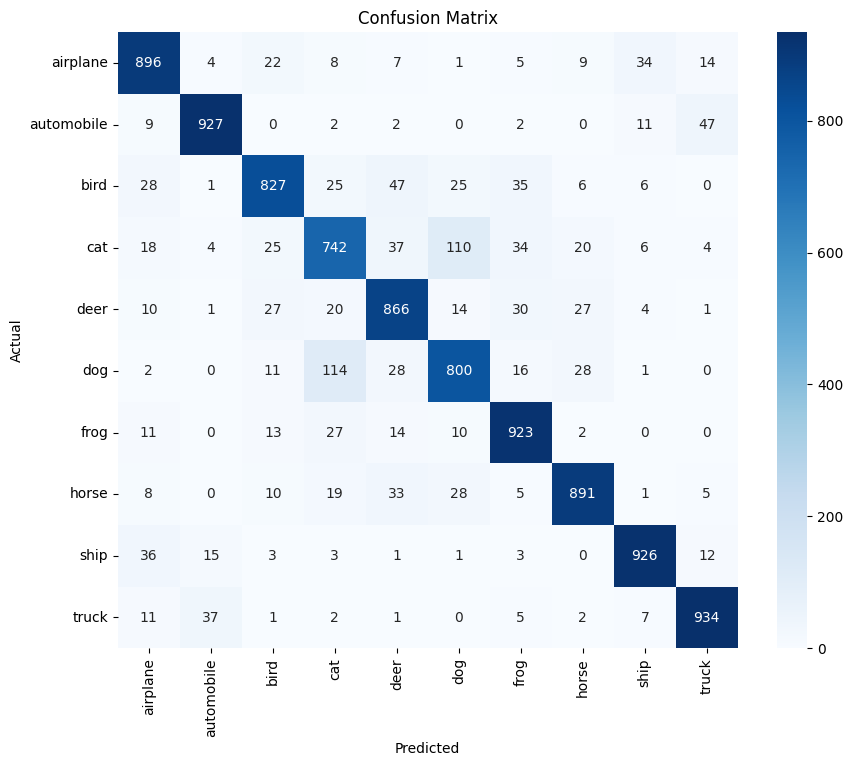

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true_labels,
    y_pred_labels
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [10]:
model.save("mobilenetv1_cifar10.h5")

import os

size_mb = os.path.getsize(
    "mobilenetv1_cifar10.h5"
)/(1024*1024)

print("Model Size:", size_mb, "MB")

Model Size: 37.24951171875 MB
